# Task 3 — Data Visualization & Dashboarding
**ApexPlanet Data Analytics Internship**  
**Dataset:** E-commerce Sales (Cleaned)  
**Timeline:** 7 Days (Day 14–20)

---

## 📋 What We Cover
| Days | Topic |
|------|-------|
| Day 14–15 | Python Visualization (Matplotlib + Seaborn) |
| Day 16–18 | Advanced Interactive Plots (Plotly) |
| Day 19–20 | Full Interactive Executive Dashboard (Plotly) |

---

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load Cleaned Dataset

In [2]:
df = pd.read_csv('../data/data_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
df.head(3)

✅ Dataset loaded: 333,234 rows × 12 columns
Date range: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,1,22.00


---
## 🔧 Step 3: Prepare Aggregated Data (Used Across All Charts)

In [3]:
# Monthly revenue
monthly = (
    df.groupby(['Year', 'Month'])
    .agg(Revenue=('TotalPrice', 'sum'),
         Orders=('InvoiceNo', 'nunique'),
         Customers=('CustomerID', 'nunique'))
    .reset_index()
)
monthly['Period'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
)
monthly.sort_values('Period', inplace=True)

# Top 10 countries
top_countries = (
    df.groupby('Country')
    .agg(Revenue=('TotalPrice', 'sum'),
         Customers=('CustomerID', 'nunique'))
    .sort_values('Revenue', ascending=False)
    .head(10)
    .reset_index()
)

# Top 10 products
top_products = (
    df.groupby('Description')
    .agg(Revenue=('TotalPrice', 'sum'),
         Quantity=('Quantity', 'sum'))
    .sort_values('Revenue', ascending=False)
    .head(10)
    .reset_index()
)

# Customer segments
customer_spend = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_spend.columns = ['CustomerID', 'TotalSpend']
customer_spend['Segment'] = pd.cut(
    customer_spend['TotalSpend'],
    bins=[0, 200, 1000, 5000, float('inf')],
    labels=['Occasional (<£200)', 'Low Value (£200-£999)',
            'Mid Value (£1K-£5K)', 'High Value (>£5K)']
)
segment_counts = customer_spend['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

print('✅ All aggregations ready!')

✅ All aggregations ready!


---
# 📅 DAY 14–15: PYTHON VISUALIZATION
## Part A — Matplotlib Charts

### 📈 Chart 1 — Line Chart: Monthly Revenue Trend

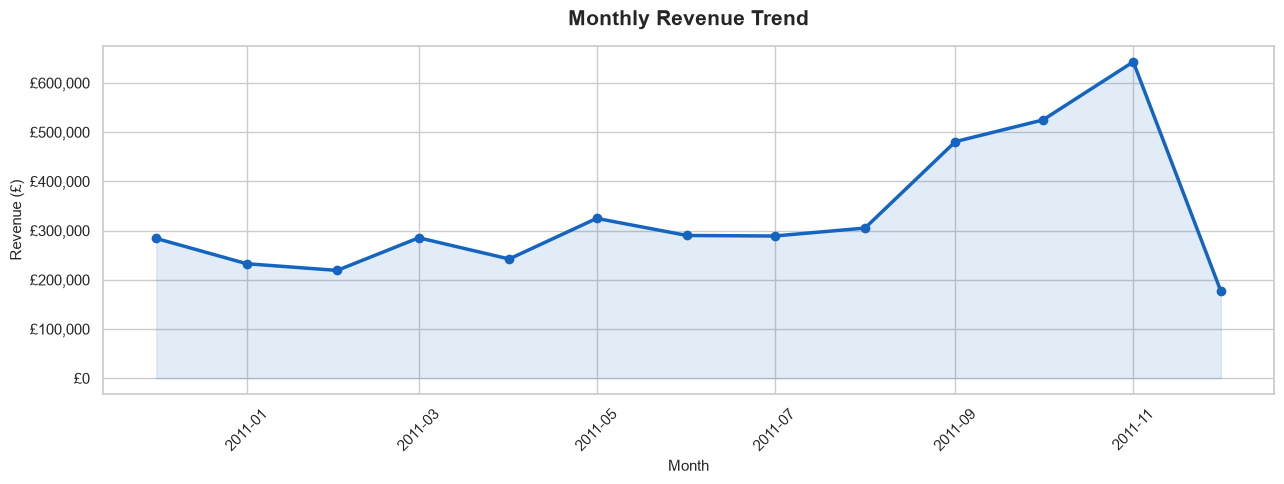

✅ Saved: reports/viz_line_monthly_revenue.png


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly['Period'], monthly['Revenue'],
        color='#1565C0', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(monthly['Period'], monthly['Revenue'],
                alpha=0.12, color='#1565C0')

ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/viz_line_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_line_monthly_revenue.png')

### 📊 Chart 2 — Bar Chart: Top 10 Countries by Revenue

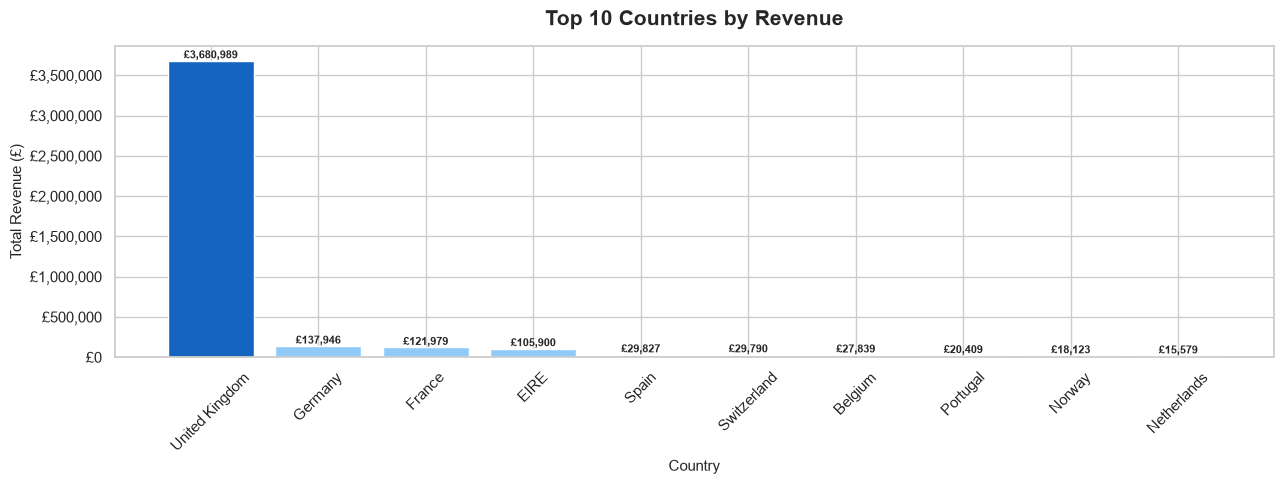

✅ Saved: reports/viz_bar_countries.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(top_countries))]
bars = ax.bar(top_countries['Country'], top_countries['Revenue'], color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'£{bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Top 10 Countries by Revenue', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Total Revenue (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/viz_bar_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_bar_countries.png')

### 📊 Chart 3 — Horizontal Bar Chart: Top 10 Products by Revenue

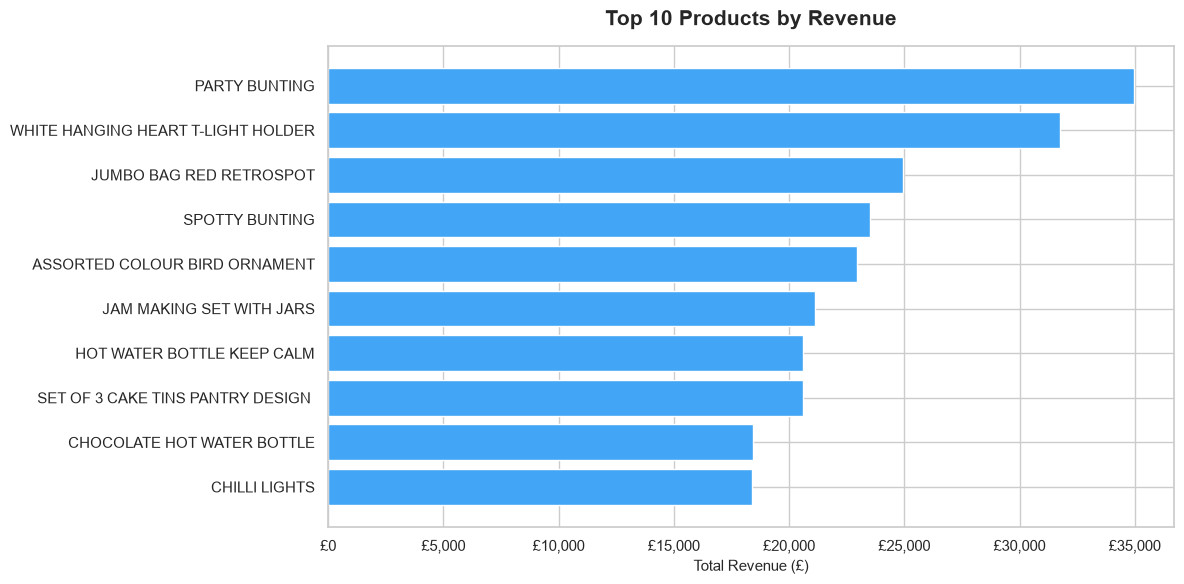

✅ Saved: reports/viz_bar_products.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

top_products_sorted = top_products.sort_values('Revenue')
ax.barh(top_products_sorted['Description'],
        top_products_sorted['Revenue'],
        color='#42A5F5', edgecolor='white')

ax.set_title('Top 10 Products by Revenue', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/viz_bar_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_bar_products.png')

### 📊 Chart 4 — Scatter Plot: Quantity vs Unit Price

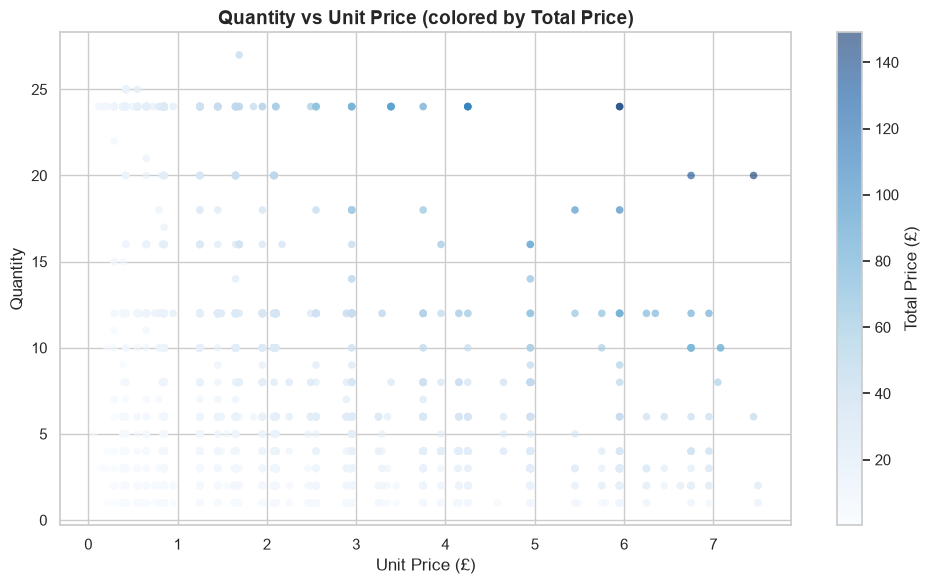

✅ Saved: reports/viz_scatter_qty_price.png


In [7]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['UnitPrice'], sample['Quantity'],
    c=sample['TotalPrice'], cmap='Blues',
    alpha=0.6, edgecolors='none', s=30
)
plt.colorbar(scatter, label='Total Price (£)')
ax.set_title('Quantity vs Unit Price (colored by Total Price)', fontsize=14, fontweight='bold')
ax.set_xlabel('Unit Price (£)')
ax.set_ylabel('Quantity')
plt.tight_layout()
plt.savefig('../reports/viz_scatter_qty_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_scatter_qty_price.png')

### 📊 Chart 5 — Histogram: Total Price Distribution

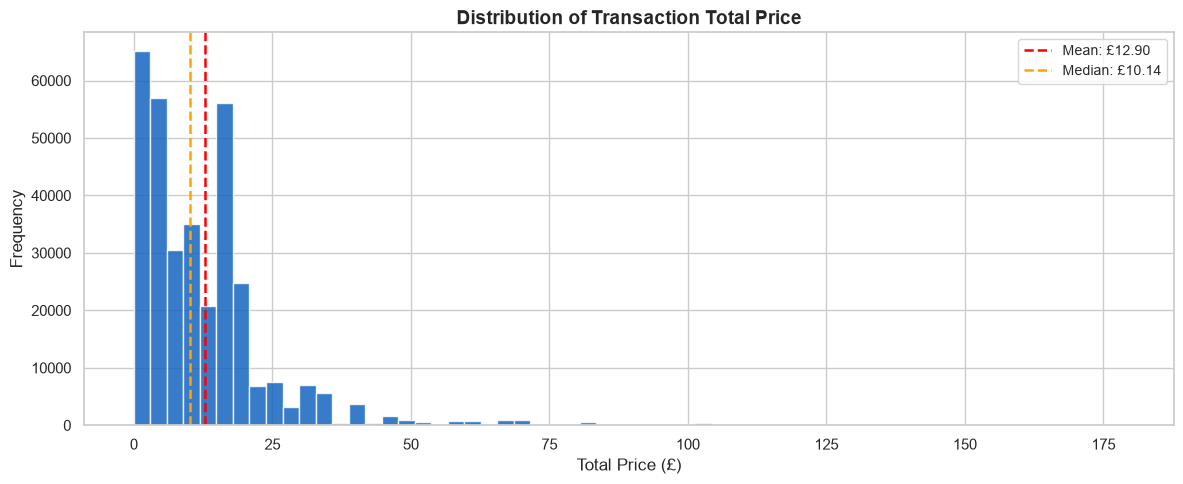

✅ Saved: reports/viz_hist_totalprice.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['TotalPrice'], bins=60, color='#1565C0',
        edgecolor='white', alpha=0.85)
ax.axvline(df['TotalPrice'].mean(), color='red',
           linestyle='--', linewidth=1.8, label=f'Mean: £{df["TotalPrice"].mean():.2f}')
ax.axvline(df['TotalPrice'].median(), color='orange',
           linestyle='--', linewidth=1.8, label=f'Median: £{df["TotalPrice"].median():.2f}')

ax.set_title('Distribution of Transaction Total Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Price (£)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/viz_hist_totalprice.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_hist_totalprice.png')

---
## Part B — Seaborn Advanced Charts

### 🔥 Chart 6 — Heatmap: Monthly Revenue by Year

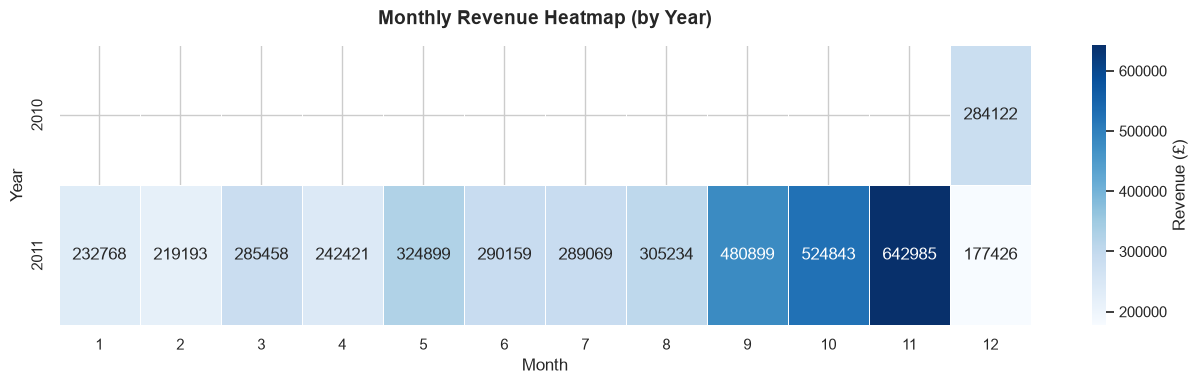

✅ Saved: reports/viz_heatmap_monthly.png


In [9]:
pivot = df.pivot_table(
    values='TotalPrice', index='Year',
    columns='Month', aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot, annot=True, fmt='.0f',
    cmap='Blues', linewidths=0.5,
    cbar_kws={'label': 'Revenue (£)'},
    ax=ax
)
ax.set_title('Monthly Revenue Heatmap (by Year)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('../reports/viz_heatmap_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_heatmap_monthly.png')

### 📦 Chart 7 — Boxen Plot: Unit Price Distribution by Top 5 Countries

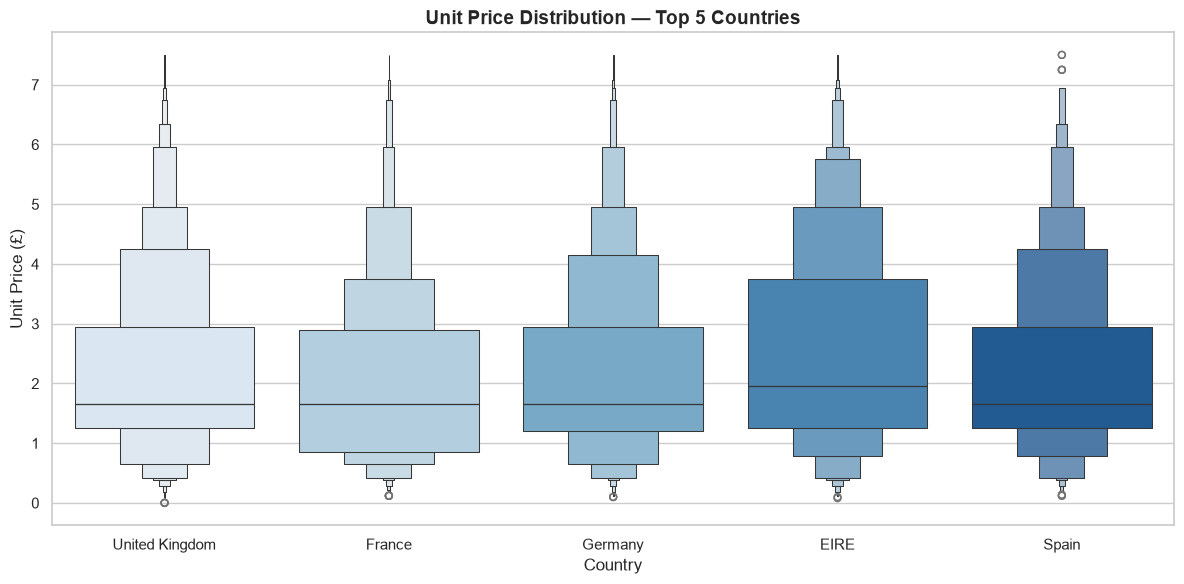

✅ Saved: reports/viz_boxen_unitprice.png


In [10]:
top5_countries = top_countries['Country'].head(5).tolist()
df_top5 = df[df['Country'].isin(top5_countries)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxenplot(
    data=df_top5, x='Country', y='UnitPrice',
    palette='Blues', ax=ax
)
ax.set_title('Unit Price Distribution — Top 5 Countries', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Unit Price (£)')
plt.tight_layout()
plt.savefig('../reports/viz_boxen_unitprice.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_boxen_unitprice.png')

### 🔗 Chart 8 — Pairplot: Numeric Variables

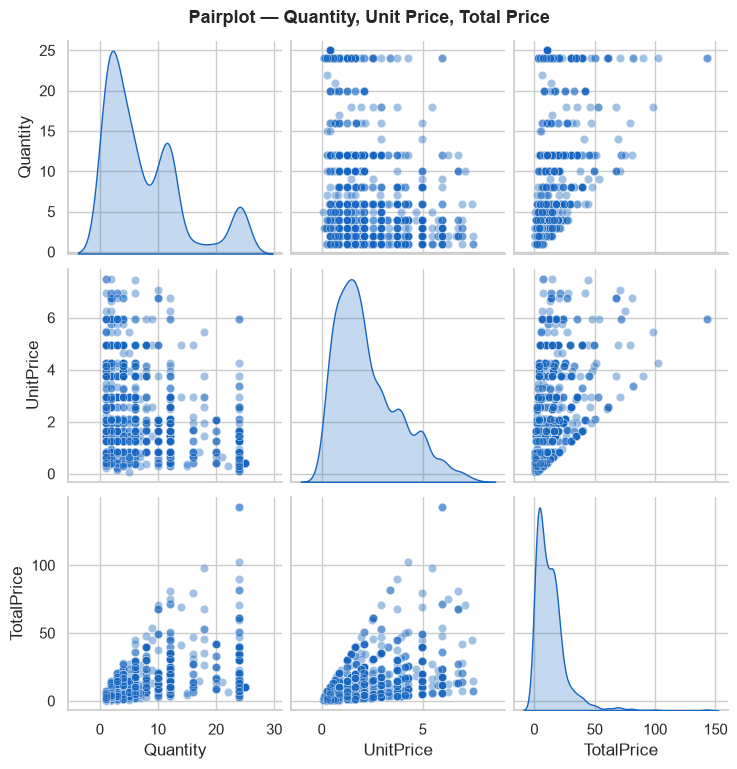

✅ Saved: reports/viz_pairplot.png


In [11]:
sample_pair = df[['Quantity', 'UnitPrice', 'TotalPrice']].sample(1500, random_state=42)

pair = sns.pairplot(sample_pair, diag_kind='kde',
                    plot_kws={'alpha': 0.4, 'color': '#1565C0'},
                    diag_kws={'color': '#1565C0'})
pair.fig.suptitle('Pairplot — Quantity, Unit Price, Total Price',
                   y=1.02, fontsize=13, fontweight='bold')
pair.savefig('../reports/viz_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_pairplot.png')

### 📊 Chart 9 — Correlation Heatmap

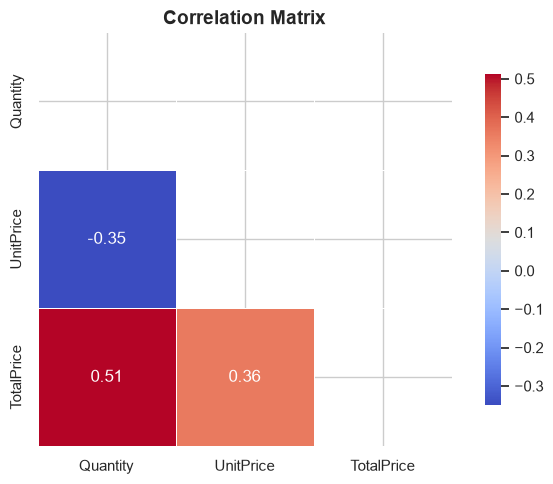

✅ Saved: reports/viz_corr_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5,
    square=True, mask=mask, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/viz_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/viz_corr_heatmap.png')

---
# 📅 DAY 16–18: INTERACTIVE PLOTS WITH PLOTLY

### 🖱️ Chart 10 — Interactive Line Chart: Monthly Revenue

In [13]:
fig = px.line(
    monthly, x='Period', y='Revenue',
    title='📈 Interactive Monthly Revenue Trend',
    labels={'Revenue': 'Revenue (£)', 'Period': 'Month'},
    markers=True,
    color_discrete_sequence=['#1565C0']
)
fig.update_traces(line_width=2.5)
fig.update_layout(
    hovermode='x unified',
    plot_bgcolor='white',
    yaxis_tickprefix='£',
    yaxis_tickformat=',.0f'
)
fig.write_html('../reports/viz_interactive_revenue.html')
fig.show()
print('✅ Saved: reports/viz_interactive_revenue.html')

✅ Saved: reports/viz_interactive_revenue.html


### 🖱️ Chart 11 — Interactive Bar Chart: Top 10 Products

In [14]:
fig = px.bar(
    top_products.sort_values('Revenue'),
    x='Revenue', y='Description',
    orientation='h',
    title='🛒 Top 10 Products by Revenue',
    labels={'Revenue': 'Revenue (£)', 'Description': 'Product'},
    color='Revenue',
    color_continuous_scale='Blues'
)
fig.update_layout(
    plot_bgcolor='white',
    xaxis_tickprefix='£',
    xaxis_tickformat=',.0f',
    showlegend=False
)
fig.write_html('../reports/viz_interactive_products.html')
fig.show()
print('✅ Saved: reports/viz_interactive_products.html')

✅ Saved: reports/viz_interactive_products.html


### 🖱️ Chart 12 — Interactive Donut Chart: Customer Segments

In [15]:
fig = px.pie(
    segment_counts, values='Count', names='Segment',
    title='👥 Customer Segmentation by Spend',
    hole=0.45,
    color_discrete_sequence=px.colors.sequential.Blues[2:]
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(showlegend=True)
fig.write_html('../reports/viz_interactive_segments.html')
fig.show()
print('✅ Saved: reports/viz_interactive_segments.html')

✅ Saved: reports/viz_interactive_segments.html


### 🖱️ Chart 13 — Interactive Scatter: Revenue vs Orders by Country

In [16]:
country_stats = (
    df.groupby('Country')
    .agg(Revenue=('TotalPrice', 'sum'),
         Orders=('InvoiceNo', 'nunique'),
         Customers=('CustomerID', 'nunique'))
    .reset_index()
)

fig = px.scatter(
    country_stats, x='Orders', y='Revenue',
    size='Customers', color='Country',
    hover_name='Country',
    title='🌍 Revenue vs Orders by Country (bubble = unique customers)',
    labels={'Revenue': 'Revenue (£)', 'Orders': 'Total Orders'},
    size_max=60
)
fig.update_layout(
    plot_bgcolor='white',
    yaxis_tickprefix='£',
    yaxis_tickformat=',.0f'
)
fig.write_html('../reports/viz_interactive_scatter.html')
fig.show()
print('✅ Saved: reports/viz_interactive_scatter.html')

✅ Saved: reports/viz_interactive_scatter.html


---
# 📅 DAY 19–20: EXECUTIVE DASHBOARD
## Full Interactive Dashboard with KPI Cards + 6 Charts

In [17]:
# ── Compute KPIs ──
total_revenue   = df['TotalPrice'].sum()
total_orders    = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products  = df['Description'].nunique()
avg_order_value = total_revenue / total_orders

print('📊 KPI Summary')
print(f'  Total Revenue   : £{total_revenue:,.2f}')
print(f'  Total Orders    : {total_orders:,}')
print(f'  Total Customers : {total_customers:,}')
print(f'  Unique Products : {total_products:,}')
print(f'  Avg Order Value : £{avg_order_value:,.2f}')

📊 KPI Summary
  Total Revenue   : £4,299,476.18
  Total Orders    : 16,826
  Total Customers : 4,191
  Unique Products : 3,575
  Avg Order Value : £255.53


In [18]:
# ── Build Executive Dashboard ──
fig = make_subplots(
    rows=4, cols=3,
    specs=[
        [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
        [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
        [{'colspan': 2, 'type': 'xy'}, None, {'type': 'domain'}],
        [{'colspan': 2, 'type': 'xy'}, None, {'type': 'xy'}]
    ],
    subplot_titles=(
        '','','',
        '','','',
        'Monthly Revenue Trend', '', 'Customer Segments',
        'Top 10 Products by Revenue', '', 'Top 10 Countries'
    ),
    vertical_spacing=0.08,
    horizontal_spacing=0.06
)

# ── Row 1 & 2: KPI Cards ──
kpis = [
    ('Total Revenue', f'£{total_revenue:,.0f}', '#1565C0'),
    ('Total Orders',  f'{total_orders:,}',       '#0288D1'),
    ('Customers',     f'{total_customers:,}',     '#00838F'),
    ('Unique Products', f'{total_products:,}',    '#558B2F'),
    ('Avg Order Value', f'£{avg_order_value:,.2f}','#6A1B9A'),
    ('Top Country', top_countries.iloc[0]['Country'], '#C62828')
]
positions = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]

for (title, val, color), (row, col) in zip(kpis, positions):
    fig.add_trace(
        go.Indicator(
            mode='number',
            value=None,
            title={'text': f'<b>{val}</b><br><span style="font-size:13px;color:gray">{title}</span>',
                   'font': {'size': 20, 'color': color}},
            number={'font': {'size': 1}}
        ),
        row=row, col=col
    )

# ── Row 3 Left: Monthly Revenue Line Chart ──
fig.add_trace(
    go.Scatter(
        x=monthly['Period'], y=monthly['Revenue'],
        mode='lines+markers',
        name='Monthly Revenue',
        line=dict(color='#1565C0', width=2.5),
        fill='tozeroy', fillcolor='rgba(21,101,192,0.1)',
        hovertemplate='%{x}<br>Revenue: £%{y:,.0f}<extra></extra>'
    ),
    row=3, col=1
)

# ── Row 3 Right: Customer Segment Donut ──
fig.add_trace(
    go.Pie(
        labels=segment_counts['Segment'],
        values=segment_counts['Count'],
        hole=0.45,
        name='Segments',
        marker_colors=['#1565C0','#42A5F5','#90CAF9','#BBDEFB'],
        hovertemplate='%{label}<br>Count: %{value}<br>Share: %{percent}<extra></extra>'
    ),
    row=3, col=3
)

# ── Row 4 Left: Top 10 Products Bar ──
tp_sorted = top_products.sort_values('Revenue')
fig.add_trace(
    go.Bar(
        x=tp_sorted['Revenue'],
        y=tp_sorted['Description'],
        orientation='h',
        name='Revenue',
        marker_color='#1565C0',
        hovertemplate='%{y}<br>Revenue: £%{x:,.0f}<extra></extra>'
    ),
    row=4, col=1
)

# ── Row 4 Right: Top 10 Countries Bar ──
tc_sorted = top_countries.sort_values('Revenue')
fig.add_trace(
    go.Bar(
        x=tc_sorted['Revenue'],
        y=tc_sorted['Country'],
        orientation='h',
        name='Country Revenue',
        marker_color='#42A5F5',
        hovertemplate='%{y}<br>Revenue: £%{x:,.0f}<extra></extra>'
    ),
    row=4, col=3
)

# ── Layout ──
fig.update_layout(
    title=dict(
        text='<b>🛒 E-Commerce Sales — Executive Dashboard</b><br><sup>ApexPlanet Data Analytics Internship | Task 3</sup>',
        font=dict(size=20),
        x=0.5
    ),
    height=1100,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='#F8F9FA',
    font=dict(family='Arial', size=11)
)

# Format axes
fig.update_xaxes(tickprefix='£', tickformat=',.0f', row=4, col=1)
fig.update_xaxes(tickprefix='£', tickformat=',.0f', row=4, col=3)
fig.update_yaxes(tickprefix='£', tickformat=',.0f', row=3, col=1)

fig.write_html('../dashboards/executive_dashboard.html')
fig.show()
print('✅ Executive Dashboard saved to dashboards/executive_dashboard.html')

✅ Executive Dashboard saved to dashboards/executive_dashboard.html


---
## 💡 Key Visual Insights

In [19]:
print('=' * 65)
print('          📌 KEY INSIGHTS FROM VISUALIZATIONS')
print('=' * 65)

peak_month = monthly.loc[monthly['Revenue'].idxmax()]
low_month  = monthly.loc[monthly['Revenue'].idxmin()]

print(f"""
1️⃣  PEAK REVENUE MONTH:
   {peak_month['Period'].strftime('%B %Y')} was the highest revenue month
   with £{peak_month['Revenue']:,.0f} in sales.

2️⃣  LOWEST REVENUE MONTH:
   {low_month['Period'].strftime('%B %Y')} recorded the lowest revenue
   at £{low_month['Revenue']:,.0f} — possibly impacted by seasonality.

3️⃣  TOP COUNTRY:
   {top_countries.iloc[0]['Country']} leads with £{top_countries.iloc[0]['Revenue']:,.0f} revenue,
   far ahead of all other markets.

4️⃣  CUSTOMER SEGMENTS:
   Most customers fall in the 'Occasional' or 'Low Value' tier,
   showing room to upsell and move customers to higher value tiers.

5️⃣  PRODUCT CONCENTRATION:
   Top 10 products out of {total_products:,} unique items drive a
   disproportionate share of total revenue — focus marketing here.
""")
print('=' * 65)

          📌 KEY INSIGHTS FROM VISUALIZATIONS

1️⃣  PEAK REVENUE MONTH:
   November 2011 was the highest revenue month
   with £642,985 in sales.

2️⃣  LOWEST REVENUE MONTH:
   December 2011 recorded the lowest revenue
   at £177,426 — possibly impacted by seasonality.

3️⃣  TOP COUNTRY:
   United Kingdom leads with £3,680,989 revenue,
   far ahead of all other markets.

4️⃣  CUSTOMER SEGMENTS:
   Most customers fall in the 'Occasional' or 'Low Value' tier,
   showing room to upsell and move customers to higher value tiers.

5️⃣  PRODUCT CONCENTRATION:
   Top 10 products out of 3,575 unique items drive a
   disproportionate share of total revenue — focus marketing here.



---
## ✅ Task 3 Complete!

**What we accomplished:**
- ✅ Created 9 static charts using Matplotlib & Seaborn (line, bar, scatter, histogram, heatmap, boxen, pairplot, correlation)
- ✅ Created 4 interactive charts using Plotly (line, bar, donut, bubble scatter)
- ✅ Built a full Executive Dashboard with KPI cards + 4 charts saved as HTML
- ✅ All charts exported as PNG and HTML to `reports/` and `dashboards/`
- ✅ Documented 5 key visual insights

**Next Steps:**
1. Push notebooks + reports + dashboard to GitHub
2. Record a screen recording showing the dashboard
3. Post on LinkedIn with a screenshot of the dashboard
4. Submit on ApexPlanet portal
5. Move to **Task 4 — Advanced Analytics** 🚀

---
*ApexPlanet Data Analytics Internship — Task 3 of 5*